In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
def wrangle(path, set_col_name):
    # Load data
    df = pd.read_csv(path, skiprows=1)

    # Convert first column to datetime 
    df['date'] = pd.to_datetime(df['unix'], unit = "s")
    df = df.sort_values(by='date', ascending=True)

    # Set index
    df.set_index('date', inplace=True)

    # Only leave the 'close' column
    df = df[['close']]

    # Rename columns
    df = df.rename(columns={'close': set_col_name})

    return df

In [3]:
Bitcoin = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_BTCUSD_1h.csv",
             'BTC')
Ether = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_ETHUSD_1h.csv",
                'ETH')
XRP = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_XRPUSD_1h.csv",
              'XRP')


In [4]:
df = pd.merge(Bitcoin, Ether, on='date', how='outer')
df = pd.merge(df, XRP, on='date', how='outer')

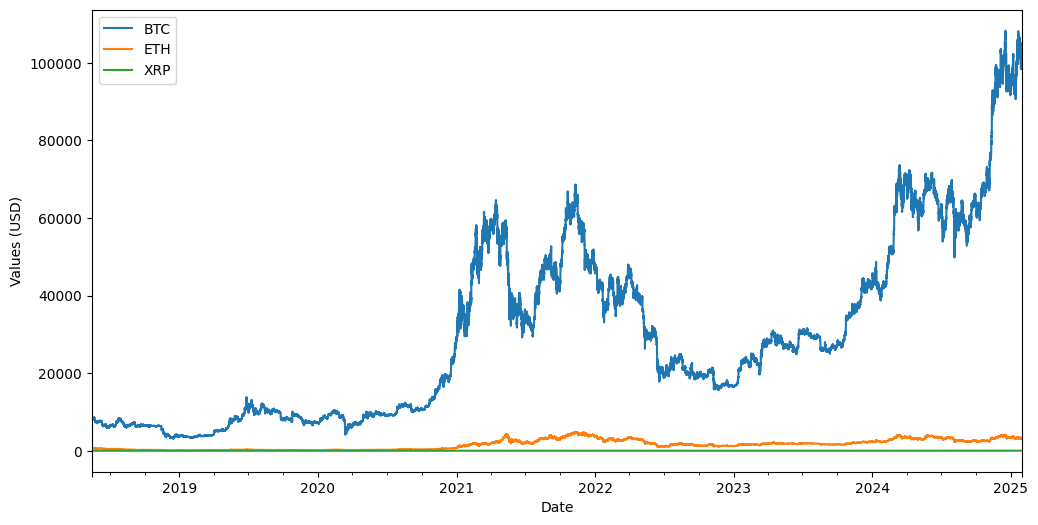

In [5]:
df.plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Values (USD)');